# Brazil Mid-Market Deals Radar

A small, reproducible tracker of **Brazilian mid-market deal flow** — announced
M&A, private equity, venture, and select debt — read through a credit lens.
Everything runs top-to-bottom in this notebook: generate a synthetic demo
dataset, validate it, and profile the **most active acquirers** over a trailing
12-month window, with a scaffold for a later **public** credit-stress overlay.

The value on show is the **framework**: a clean data model, validation,
acquirer-name canonicalization, and a reproducible analysis — not statistical
breadth. I approach this as a **deals generalist who brings a sharper credit lens
to diligence**, treating leverage and credit quality as part of how you read a
transaction rather than as a distressed-only specialty.

> **Portfolio / practice build.** The dataset here is **synthetic**, generated
> below with a fixed seed. Every row carries `source = SYNTHETIC-EXAMPLE` and uses
> fictional placeholder names, so no real transaction is implied. To use this for
> real, replace the synthetic rows and log actual deals from **public** sources
> via the `add_deal(...)` helper near the end.

*Just run all cells.* Requirements: `pandas`, `matplotlib`
(`pip install pandas matplotlib`).

## 0 · Configuration

In [1]:
import csv, datetime as dt, difflib, os, random
import pandas as pd
import matplotlib.pyplot as plt

# Editable knobs
SEED         = 42      # reproducible synthetic draw
N_DEALS      = 55      # how many synthetic deals to create
TOP_N        = 10      # acquirers shown in each headline chart
WINDOW_DAYS  = 365     # trailing coverage window, anchored on the latest deal
DEALS_FILE   = "deals.csv"
FIG_DIR      = "figures"

# If deals.csv already exists, we reuse it (so you don't overwrite real entries).
# Flip this to True to always regenerate the synthetic demo dataset.
FORCE_REGENERATE = False

os.makedirs(FIG_DIR, exist_ok=True)

# Schema (column order is used verbatim by the tooling)
COLUMNS = ["deal_id","announce_date","target","acquirer_raw","acquirer_canonical",
           "acquirer_type","deal_type","sector","value_brl_mm","stake_pct",
           "source","source_url","notes"]
ACQUIRER_TYPES = ["PE","Estrategico","VC","FO"]
DEAL_TYPES     = ["M&A","PE","VC","divida","distressed"]
REQUIRED = ["deal_id","announce_date","target","acquirer_raw","acquirer_canonical",
            "acquirer_type","deal_type","sector","source","source_url"]

# Editable sector-normalization map (messy label -> tidy label).
# Unmapped sectors pass through unchanged, so nothing is silently dropped.
SECTOR_MAP = {
    "transporte e logistica":"Transporte & Logística","logistica":"Transporte & Logística",
    "alimentos e bebidas":"Alimentos & Bebidas","alimentos":"Alimentos & Bebidas",
    "saude":"Saúde","tecnologia":"Tecnologia","ti":"Tecnologia",
    "agronegocio":"Agronegócio","agro":"Agronegócio","varejo":"Varejo","energia":"Energia",
    "servicos":"Serviços","servicos financeiros":"Serviços Financeiros",
    "educacao":"Educação","construcao":"Construção","industria":"Indústria",
}

BAR = "#3b5b7d"
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,
                     "axes.spines.right":False,"font.size":11})

## 1 · Synthetic demo data

A seeded generator fabricates clearly-labeled sample deals so the charts have
something to show. This is **demo data, not collection** — there is nothing real
here to gather. Fictional acquirers use placeholder (Greek-letter) names; a few
carry spelling variants on purpose, to exercise the canonicalization step later.

In [2]:
# (canonical, type, [raw spelling variants], activity weight)
_ACQUIRERS = [
    ("Alpha Capital Partners","PE",["Alpha Capital Partners","Alpha Capital","Alpha Cap. Partners"],9),
    ("Beta Equity","PE",["Beta Equity","Beta Equity Ltda"],7),
    ("Gamma Capital","PE",["Gamma Capital"],5),
    ("Sigma Investimentos","PE",["Sigma Investimentos"],4),
    ("Omega Partners","PE",["Omega Partners","Ômega Partners"],4),
    ("Tau Capital","PE",["Tau Capital"],2),
    ("Grupo Delta","Estrategico",["Grupo Delta","Grupo Delta S.A."],6),
    ("Epsilon Industria","Estrategico",["Epsilon Industria","Épsilon Indústria"],4),
    ("Holding Zeta","Estrategico",["Holding Zeta"],3),
    ("Grupo Ni","Estrategico",["Grupo Ni","Grupo Ni Holding"],2),
    ("Kappa Ventures","VC",["Kappa Ventures"],5),
    ("Lambda Ventures","VC",["Lambda Ventures"],4),
    ("Theta Ventures","VC",["Theta Ventures"],3),
    ("Phi Ventures","VC",["Phi Ventures"],2),
    ("Family Office Ikaros","FO",["Family Office Ikaros","FO Ikaros"],3),
    ("Escritorio Mu","FO",["Escritorio Mu"],2),
]
_SECTORS = ["Agronegocio","Saude","Tecnologia","Varejo","Transporte e logistica",
            "Alimentos e bebidas","Energia","Servicos financeiros","Educacao",
            "Construcao","Industria","Servicos"]
_ROOTS = ["Aurora","Bandeira","Cerrado","Dunas","Estrela","Farol","Guara","Horizonte",
          "Ipe","Jacaranda","Litoral","Marimba","Norte","Oceano","Palmares","Quartzo",
          "Raizes","Serrano","Tucano","Uniao","Verde","Xingu","Zenite","Buriti"]
_SUFFIX = {"Agronegocio":"Agro","Saude":"Saude","Tecnologia":"Tech","Varejo":"Varejo",
           "Transporte e logistica":"Log","Alimentos e bebidas":"Foods","Energia":"Energia",
           "Servicos financeiros":"Fin","Educacao":"Educa","Construcao":"Engenharia",
           "Industria":"Industrial","Servicos":"Servicos"}
_NOTES = ["Amostra sintetica. Plataforma de buy-and-build; observar alavancagem pos-deal.",
          "Amostra sintetica. Consolidacao setorial; multiplo aparentemente esticado.",
          "Amostra sintetica. Rodada minoritaria; sem controle.",
          "Amostra sintetica. Credito privado; foco em geracao de caixa do alvo.",
          "Amostra sintetica. Situacao especial; tese de turnaround.",
          "Amostra sintetica."]

def _wpick(rng, items, weights):
    return rng.choices(items, weights=weights, k=1)[0]

def _deal_type(rng, atype):
    w = {"VC":[10,8,70,2,2],"Estrategico":[70,8,5,7,5],
         "FO":[30,15,10,30,10]}.get(atype,[45,30,5,8,12])  # PE default
    return _wpick(rng, DEAL_TYPES, w)

def _value(rng, deal_type):
    if rng.random() > 0.65:
        return ""                          # ~35% undisclosed
    base = max(12, min(rng.lognormvariate(4.8, 0.7), 820))
    if deal_type == "VC":
        base = max(8, base * 0.35)
    return str(int(round(base,-1)) if base >= 100 else int(round(base)))

def _stake(rng, deal_type):
    if deal_type == "divida": return ""
    if deal_type == "VC":     return str(rng.randint(5,30))
    if deal_type in ("M&A","distressed"): return str(rng.choice([100,100,100,70,60,51,80]))
    return str(rng.choice([100,80,70,60,51,40]))

def generate_deals(n=N_DEALS, seed=SEED):
    rng = random.Random(seed)
    names   = [a[0] for a in _ACQUIRERS]
    weights = [a[3] for a in _ACQUIRERS]
    start, end = dt.date(2025,7,1), dt.date(2026,6,25)
    span = (end - start).days
    rows = []
    for _ in range(n):
        canon = _wpick(rng, names, weights)
        _, atype, variants, _ = next(a for a in _ACQUIRERS if a[0] == canon)
        sector = rng.choice(_SECTORS)
        dtp    = _deal_type(rng, atype)
        val    = _value(rng, dtp)
        rows.append({
            "announce_date": (start + dt.timedelta(days=rng.randint(0, span))).isoformat(),
            "target": f"{rng.choice(_ROOTS)} {_SUFFIX[sector]}",
            "acquirer_raw": rng.choice(variants), "acquirer_canonical": canon,
            "acquirer_type": atype, "deal_type": dtp, "sector": sector,
            "value_brl_mm": val, "stake_pct": _stake(rng, dtp),
            "source": "SYNTHETIC-EXAMPLE",
            "notes": ("Amostra sintetica. Valor nao divulgado pelas partes."
                      if val == "" else rng.choice(_NOTES)),
        })
    rows.sort(key=lambda r: r["announce_date"])
    for i, r in enumerate(rows, 1):
        r["deal_id"] = str(i); r["source_url"] = f"https://example.com/synthetic/{i}"
    return rows

def write_csv(rows, path=DEALS_FILE):
    with open(path, "w", newline="", encoding="utf-8") as fh:
        w = csv.DictWriter(fh, fieldnames=COLUMNS); w.writeheader()
        for r in rows: w.writerow({c: r.get(c,"") for c in COLUMNS})

if FORCE_REGENERATE or not os.path.exists(DEALS_FILE):
    write_csv(generate_deals())
    print(f"Generated {N_DEALS} synthetic deals -> {DEALS_FILE} (seed={SEED}).")
else:
    print(f"Using existing {DEALS_FILE} (set FORCE_REGENERATE=True to overwrite).")

Generated 55 synthetic deals -> deals.csv (seed=42).


## 2 · Validate

The same integrity checks the CLI ran: schema, types, ranges, unique/sequential ids.

In [3]:
def _iso(v):
    try: dt.date.fromisoformat(v); return True
    except (ValueError, TypeError): return False
def _blank(v): return v is None or str(v).strip() == ""
def _num(v, lo=None, hi=None):
    try: n = float(v)
    except (ValueError, TypeError): return False
    return (lo is None or n >= lo) and (hi is None or n <= hi)

def validate(path=DEALS_FILE):
    problems = []
    with open(path, newline="", encoding="utf-8") as fh:
        reader = csv.DictReader(fh); header = reader.fieldnames or []
        rows = [dict(r) for r in reader]
    if header != COLUMNS:
        return [f"Header mismatch: {header}"]
    seen = {}
    for i, row in enumerate(rows, 1):
        loc = f"row {i} (deal_id={row.get('deal_id','?')})"
        for f in REQUIRED:
            if _blank(row.get(f)): problems.append(f"{loc}: '{f}' blank.")
        did = row.get("deal_id","")
        if not _blank(did):
            if not did.isdigit(): problems.append(f"{loc}: deal_id not integer.")
            elif did in seen: problems.append(f"{loc}: duplicate deal_id.")
            else: seen[did] = i
        if not _blank(row.get("announce_date")) and not _iso(row["announce_date"]):
            problems.append(f"{loc}: bad announce_date.")
        if row.get("acquirer_type") not in ACQUIRER_TYPES:
            problems.append(f"{loc}: bad acquirer_type.")
        if row.get("deal_type") not in DEAL_TYPES:
            problems.append(f"{loc}: bad deal_type.")
        if not _blank(row.get("value_brl_mm")) and not _num(row["value_brl_mm"], lo=0):
            problems.append(f"{loc}: bad value_brl_mm.")
        if not _blank(row.get("stake_pct")) and not _num(row["stake_pct"], lo=0, hi=100):
            problems.append(f"{loc}: bad stake_pct.")
    ids = [int(r["deal_id"]) for r in rows if r["deal_id"].isdigit()]
    if len(ids) == len(rows) and sorted(ids) != list(range(1, len(rows)+1)):
        problems.append("deal_id not a clean 1..N run.")
    return problems

issues = validate()
print("OK — validation passed." if not issues else f"FAIL — {len(issues)} issue(s):")
for p in issues: print("  -", p)
assert not issues, "Fix the dataset before continuing."

OK — validation passed.


## 3 · Load & clean

Parse dates and numerics, normalize sectors, spot-check the acquirer
canonicalization, and restrict to the trailing-12-month window anchored on the
**latest** `announce_date`. All acquirer analysis groups on `acquirer_canonical`.

In [4]:
df = pd.read_csv(DEALS_FILE, dtype=str).fillna("")
df["announce_date"] = pd.to_datetime(df["announce_date"], errors="coerce")
df["value_brl_mm"]  = pd.to_numeric(df["value_brl_mm"], errors="coerce")   # blank -> NaN
df["stake_pct"]     = pd.to_numeric(df["stake_pct"], errors="coerce")
df["sector_norm"]   = df["sector"].map(lambda s: SECTOR_MAP.get(str(s).strip().lower(), str(s).strip()))

print("acquirer_canonical  <-  distinct acquirer_raw spellings folded in:")
for canon, raws in df.groupby("acquirer_canonical")["acquirer_raw"].agg(lambda s: sorted(set(s))).items():
    flag = "  <-- multiple spellings" if len(raws) > 1 else ""
    print(f"  {canon}: {raws}{flag}")

anchor = df["announce_date"].max()
start  = anchor - pd.Timedelta(days=WINDOW_DAYS)
window = df[df["announce_date"].between(start, anchor)].copy()
print(f"\nCoverage window: {start.date()} -> {anchor.date()}  ({len(window)} of {len(df)} rows).")
df.head()

acquirer_canonical  <-  distinct acquirer_raw spellings folded in:
  Alpha Capital Partners: ['Alpha Cap. Partners', 'Alpha Capital', 'Alpha Capital Partners']  <-- multiple spellings
  Beta Equity: ['Beta Equity', 'Beta Equity Ltda']  <-- multiple spellings
  Escritorio Mu: ['Escritorio Mu']
  Family Office Ikaros: ['FO Ikaros']
  Gamma Capital: ['Gamma Capital']
  Grupo Delta: ['Grupo Delta', 'Grupo Delta S.A.']  <-- multiple spellings
  Holding Zeta: ['Holding Zeta']
  Kappa Ventures: ['Kappa Ventures']
  Lambda Ventures: ['Lambda Ventures']
  Omega Partners: ['Omega Partners', 'Ômega Partners']  <-- multiple spellings
  Phi Ventures: ['Phi Ventures']
  Sigma Investimentos: ['Sigma Investimentos']
  Tau Capital: ['Tau Capital']
  Theta Ventures: ['Theta Ventures']

Coverage window: 2025-06-22 -> 2026-06-22  (55 of 55 rows).


,deal_id,announce_date,target,acquirer_raw,acquirer_canonical,acquirer_type,deal_type,sector,value_brl_mm,stake_pct,source,source_url,notes,sector_norm
0,1,2025-07-03,Dunas Energia,Sigma Investimentos,Sigma Investimentos,PE,M&A,Energia,NaN,100.0,SYNTHETIC-EXAMPLE,https://example.com/synthetic/1,Amostra sintetica. Valor nao divulgado pelas p...,Energia
1,2,2025-07-23,Zenite Servicos,Ômega Partners,Omega Partners,PE,VC,Servicos,77.0,5.0,SYNTHETIC-EXAMPLE,https://example.com/synthetic/2,Amostra sintetica. Situacao especial; tese de ...,Serviços
2,3,2025-07-29,Horizonte Industrial,Sigma Investimentos,Sigma Investimentos,PE,PE,Industria,49.0,70.0,SYNTHETIC-EXAMPLE,https://example.com/synthetic/3,Amostra sintetica. Credito privado; foco em ge...,Indústria
3,4,2025-07-30,Tucano Educa,Escritorio Mu,Escritorio Mu,FO,divida,Educacao,75.0,NaN,SYNTHETIC-EXAMPLE,https://example.com/synthetic/4,Amostra sintetica.,Educação
4,5,2025-08-05,Bandeira Log,Alpha Cap. Partners,Alpha Capital Partners,PE,divida,Transporte e logistica,340.0,NaN,SYNTHETIC-EXAMPLE,https://example.com/synthetic/5,Amostra sintetica. Consolidacao setorial; mult...,Transporte & Logística


## 4 · Most active acquirers — by deal count

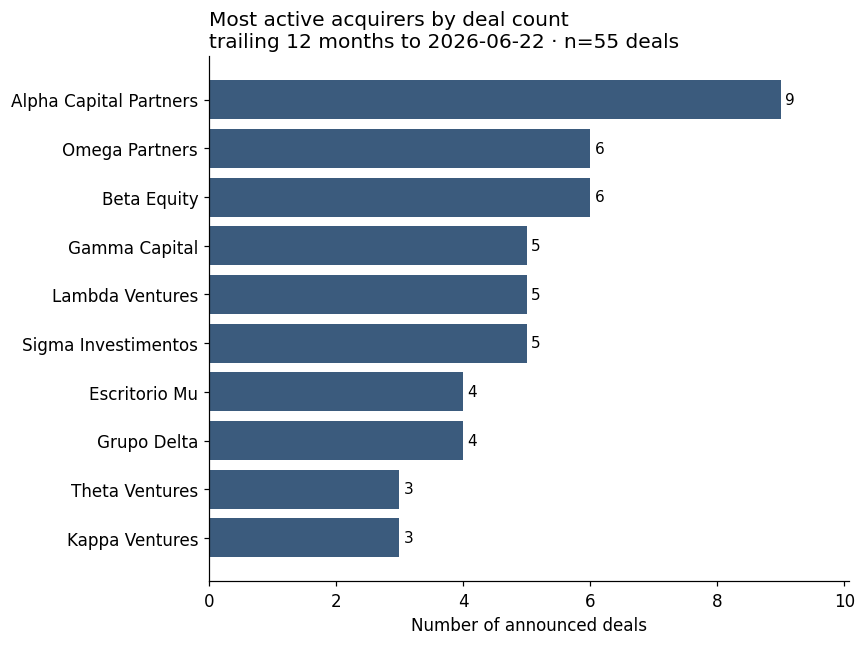

In [5]:
by_count = window.groupby("acquirer_canonical").size().sort_values().tail(TOP_N)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.5*len(by_count)+1)))
bars = ax.barh(by_count.index, by_count.values, color=BAR)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Number of announced deals")
ax.set_title(f"Most active acquirers by deal count\ntrailing 12 months to "
             f"{anchor.date()} · n={len(window)} deals", loc="left")
ax.margins(x=0.12); fig.tight_layout()
fig.savefig(f"{FIG_DIR}/acquirers_by_count.png", bbox_inches="tight")
plt.show()

## 5 · Most active acquirers — by disclosed value

Undisclosed values are excluded, and the excluded count is reported.

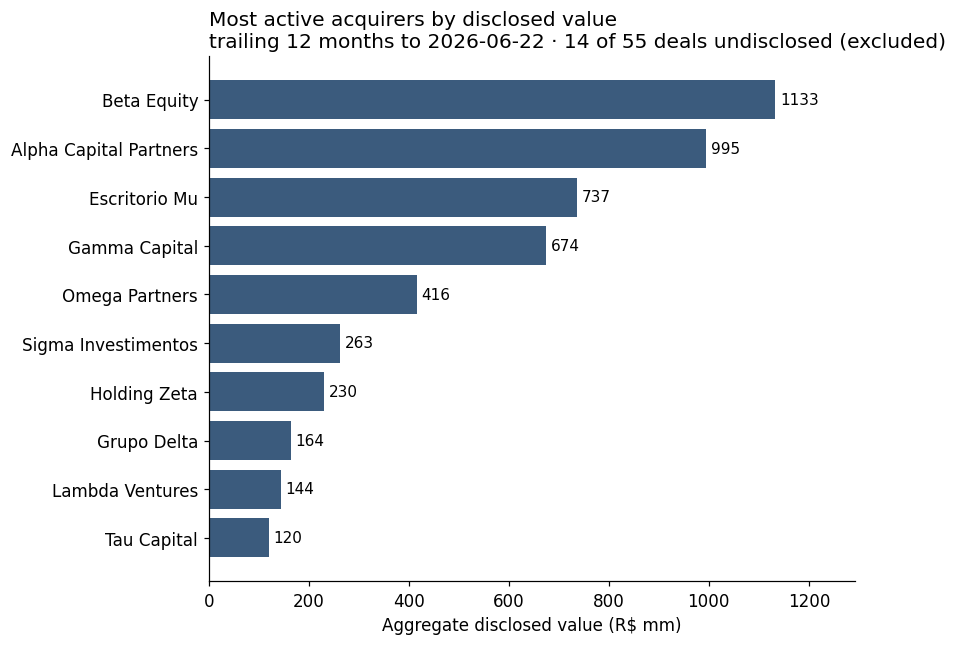

14 of 55 deals had undisclosed value and are excluded from the value chart.


In [6]:
disclosed = window[window["value_brl_mm"].notna()]
n_excl = len(window) - len(disclosed)
by_value = disclosed.groupby("acquirer_canonical")["value_brl_mm"].sum().sort_values().tail(TOP_N)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.5*len(by_value)+1)))
bars = ax.barh(by_value.index, by_value.values, color=BAR)
ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=10)
ax.set_xlabel("Aggregate disclosed value (R$ mm)")
ax.set_title(f"Most active acquirers by disclosed value\ntrailing 12 months to "
             f"{anchor.date()} · {n_excl} of {len(window)} deals undisclosed (excluded)", loc="left")
ax.margins(x=0.14); fig.tight_layout()
fig.savefig(f"{FIG_DIR}/acquirers_by_value.png", bbox_inches="tight")
plt.show()
print(f"{n_excl} of {len(window)} deals had undisclosed value and are excluded from the value chart.")

## 6 · Profile cuts

Descriptive slices by acquirer type, deal type, and normalized sector.

In [7]:
def cut(col, label):
    t = (window.groupby(col)
               .agg(deals=("deal_id","size"), disclosed_value_brl_mm=("value_brl_mm","sum"))
               .sort_values("deals", ascending=False))
    print(f"— By {label} —"); print(t.to_string()); print()

cut("acquirer_type", "acquirer type")
cut("deal_type", "deal type")
cut("sector_norm", "sector (normalized)")

— By acquirer type —
               deals  disclosed_value_brl_mm
acquirer_type                               
PE                32                  3601.0
VC                13                   263.0
FO                 5                   737.0
Estrategico        5                   394.0

— By deal type —
            deals  disclosed_value_brl_mm
deal_type                                
M&A            21                  1924.0
VC             14                   374.0
PE             10                  1301.0
divida          8                  1076.0
distressed      2                   320.0

— By sector (normalized) —
                        deals  disclosed_value_brl_mm
sector_norm                                          
Educação                   10                   968.0
Agronegócio                 8                   589.0
Varejo                      8                   805.0
Serviços                    7                   680.0
Alimentos & Bebidas         4                

## 7 · Log a real deal *(optional)*

To add an actual, publicly-sourced deal, call `add_deal(...)` in a cell. It
assigns the next `deal_id`, suggests a canonical acquirer name (fuzzy-matched
against existing ones to avoid near-duplicates), appends to `deals.csv`, and
re-validates. Manual entry only — nothing is fetched.

In [8]:
def suggest_canonical(raw, existing):
    m = difflib.get_close_matches(raw, list(existing), n=1, cutoff=0.6)
    return m[0] if m else raw

def add_deal(announce_date, target, acquirer_raw, acquirer_type, deal_type, sector,
             source, source_url, value_brl_mm="", stake_pct="", notes="",
             acquirer_canonical=None, path=DEALS_FILE):
    with open(path, newline="", encoding="utf-8") as fh:
        rows = list(csv.DictReader(fh))
    next_id = max((int(r["deal_id"]) for r in rows if r["deal_id"].isdigit()), default=0) + 1
    existing = {r["acquirer_canonical"] for r in rows if r.get("acquirer_canonical")}
    canon = acquirer_canonical or suggest_canonical(acquirer_raw, existing)
    rows.append({"deal_id":str(next_id),"announce_date":announce_date,"target":target,
                 "acquirer_raw":acquirer_raw,"acquirer_canonical":canon,
                 "acquirer_type":acquirer_type,"deal_type":deal_type,"sector":sector,
                 "value_brl_mm":str(value_brl_mm),"stake_pct":str(stake_pct),
                 "source":source,"source_url":source_url,"notes":notes})
    write_csv(rows, path)
    issues = validate(path)
    print(f"Added deal_id {next_id} (acquirer_canonical='{canon}'). "
          + ("Validation OK." if not issues else f"WARNING: {len(issues)} issue(s)."))
    return next_id

# Example (uncomment, edit with a real public deal, and re-run cells 3-6):
# add_deal("2026-06-30", "Real Target Co", "Some Fund", "PE", "M&A", "Tecnologia",
#          "Brazil Journal", "https://braziljournal.com/...", value_brl_mm=150, stake_pct=100,
#          notes="Public source; credit note here.")
print("add_deal() ready. Log real deals from public sources only.")

add_deal() ready. Log real deals from public sources only.


## 8 · Phase 2 scaffold — credit × deals overlay *(not yet wired)*

**Goal.** Overlay **public** sector-level credit-stress signals against deal
activity to surface where transactions cluster in stressed sectors — a diligence
lens, not distressed self-branding. **Public inputs only, each citable.**

Candidate public stress indicators (sourced shortlist, none wired in yet):

| Indicator | Proxies | Public source |
|---|---|---|
| Sector NPL / default ratios | Credit deterioration | Banco Central do Brasil (SGS) |
| Net debt / EBITDA of B3 names by sector | Leverage build-up | Company filings via CVM; B3 |
| Judicial recovery filings by sector | Realized distress | Serasa Experian; public courts |
| Sector activity / confidence indices | Demand-side stress | IBGE (PMS/PMC/PIM); FGV/IBRE |
| Credit spreads / debenture yields | Market-priced risk | ANBIMA |

Planned method: pick one public series → aggregate deal activity to `sector_norm`
→ join → plot activity vs. stress → short methodology + limitations, cited inline.

In [9]:
def build_credit_overlay(window_df, stress_by_sector):
    # Phase 2: join sector deal activity to a chosen PUBLIC stress series
    # (indexed by the same normalized sector labels). Not implemented yet.
    raise NotImplementedError("Phase 2: wire a chosen public stress series here.")
print("Phase 2 scaffold present; no live data wired in yet (by design).")

Phase 2 scaffold present; no live data wired in yet (by design).


## 9 · Limitations

- **Small, synthetic sample** for this build — counts and sums illustrate the
  framework, not a market census.
- **Disclosure bias** — many deal values are undisclosed; the value chart covers
  only the disclosed subset (excluded count reported).
- **Manual canonicalization** — grouping quality depends on entry discipline.
- **Announced ≠ closed** — announcements can be renegotiated or fall through.
- **Public sources only**, by design — which bounds what can be measured, and is
  the point: everything is reproducible from citable public information.